# 3Di Alignment Benchmark

## Description

We compare the performance of ESM3Di against ProstT5 on the MetaVR sequence set.

We have 3 different 3Di representations of the MetaVR sequence set:
* **AF3**: 3Di generated by Foldseek based on the predicted AlphaFold3 structures of the MetaVR sequence set.
* **ProstT5**: 3Di generated by ProstT5 based on the sequences of the MetaVR sequence set.
* **ESM3Di**: 3Di generated by ESM3Di based on the sequences of the MetaVR sequence set.

We compile each representation into a Foldseek database and run Foldseek's `structurealign` module on a 1-vs-1 basis (aligning identical entries).

The results are represented as the **bitscore** of the alignment and **3Di sequence identity**.

The **bitscore** is a measure of the overall similarity between two aligned 3Di sequences. It rewards long, well-matching alignments while penalizing mismatches and gaps, with higher bitscores indicating more similar 3Di representations.

The **3Di sequence identity** is calculated as:

$$
\text{Identity} = \frac{\text{\# of residues with identical 3Di}}{\text{\# of residues}}
$$

In [1]:
import torch
import socket

print("Running on node:", socket.gethostname())
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

Running on node: dnagpu001
GPU available: True
Device name: NVIDIA A100-PCIE-40GB MIG 3g.20gb


In [2]:
import shutil
import os

# Optional: Add local foldseek directory to PATH if installed in project folder
os.environ["PATH"] += os.pathsep + "/users/fweikert/ESM3di/foldseek/bin"

if not shutil.which("foldseek"):
    raise FileNotFoundError(
        "Foldseek binary not found in PATH. "
        "Please download the standalone binary or load the appropriate cluster module."
    )
else:
    print(f"Foldseek is ready to use at: {shutil.which('foldseek')}")

Foldseek is ready to use at: /users/fweikert/miniforge3/envs/esm3di/bin/foldseek


In [2]:
import os
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- Configuration ---
#DATAPATH = Path("./data") # !! SET THIS BACK !!
DATAPATH = Path("/scratch/fweikert/data")  # !! SET THIS BACK !!
DATAPATH.mkdir(parents=True, exist_ok=True)

FS_DIR = DATAPATH / "foldseek"
META_DIR = DATAPATH / "metavr"
FS_DIR.mkdir(exist_ok=True)
META_DIR.mkdir(exist_ok=True)

# --- Utility Functions ---
def run_cmd(cmd, silent=False):
    # Pass os.environ.copy() to preserve GPU/CUDA settings
    process = subprocess.Popen(
        cmd,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,  # Merge stderr into stdout so they stream in order
        text=True,
        bufsize=1,  # Line-buffered
        env=os.environ.copy()
    )

    output_lines = []

    # Read output line-by-line in real time
    for line in iter(process.stdout.readline, ''):
        output_lines.append(line)
        if not silent:
            print(line, end='', flush=True)  # Print immediately to terminal/Jupyter

    process.stdout.close()
    return_code = process.wait()

    if return_code != 0:
        error_msg = "".join(output_lines)
        raise RuntimeError(f"Command failed with exit code {return_code}:\n{cmd}\n\nOutput:\n{error_msg}")

def write_fasta(sequences: dict[str, str], filepath: Path):
    """Writes a dictionary of {id: sequence} to a FASTA file."""
    with open(filepath, "w") as f:
        for seq_id, seq in sequences.items():
            f.write(f">{seq_id}\n{seq}\n")

def parse_fasta(fasta_path: Path) -> dict[str, str]:
    """Reads a FASTA file into a {id: sequence} dictionary."""
    seqs, hdr = {}, None
    with open(fasta_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                hdr = line[1:].split()[0]
                seqs[hdr] = ""
            elif hdr:
                seqs[hdr] += line
    return seqs

In [4]:
import tarfile
from curl_cffi import requests
from tqdm import tqdm

tar_path = META_DIR / "partial_download.tar.gz"
url = "https://www.meta-virome.org/Data/Downloads/IMGVR5_PC_3Dmodels.tar.gz"

max_bytes = 1024 * 1024 * 1024  # 1 GB cap
downloaded = 0

print("1. Downloading first 1 GB using browser TLS impersonation...")

response = requests.get(url, impersonate="chrome", stream=True)

if response.status_code != 200:
    print(f"Failed with status code: {response.status_code}")
else:
    # Stream download with progress bar
    with open(tar_path, "wb") as f, tqdm(
        total=max_bytes,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
        desc="Downloading 1GB sample",
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if not chunk:
                continue

            # Ensure we stop precisely at the 1 GB cap
            bytes_to_write = min(len(chunk), max_bytes - downloaded)
            f.write(chunk[:bytes_to_write])
            downloaded += bytes_to_write
            pbar.update(bytes_to_write)

            if downloaded >= max_bytes:
                break

    print(f"\nDownloaded {downloaded / (1024 * 1024):.2f} MB to {tar_path}")

    print("2. Extracting structures...")

    # Stream mode ("r|gz") reads sequentially and avoids pre-scanning the full file
    try:
        with tarfile.open(tar_path, "r|gz") as tar:
            while True:
                try:
                    member = tar.next()
                    if member is None:
                        break
                    tar.extract(member, path=META_DIR)
                except (EOFError, tarfile.TarError, OSError):
                    # Gracefully stop extraction at the truncated cutoff point
                    print("\nReached the end of the truncated 1 GB stream.")
                    break
    except Exception as e:
        print(f"\nExtraction finished with notice: {e}")

    # Clean up archive file
    if tar_path.exists():
        tar_path.unlink()

    # Count extracted files
    extracted_files = sum(1 for _ in META_DIR.glob("**/*") if _.is_file())
    print(f"3. Done! Total extracted files: {extracted_files}")

1. Downloading first 1 GB using browser TLS impersonation...



Downloaded 1024.00 MB to /scratch/fweikert/data/metavr/partial_download.tar.gz
2. Extracting structures...

Reached the end of the truncated 1 GB stream.
3. Done! Total extracted files: 35344


In [4]:
import os
import random
import shutil


def sample_structures(source_dir, output_dir, n_samples=500, seed=42):
    """Samples `n_samples` PDB/CIF files from source_dir into output_dir."""
    random.seed(seed)  # Fixed seed ensures reproducible sampling
    os.makedirs(output_dir, exist_ok=True)

    # Find all 3D structure files
    valid_exts = (".pdb", ".cif", ".ent", ".pdb.gz", ".cif.gz")
    all_files = [
        f
        for f in os.listdir(source_dir)
        if f.lower().endswith(valid_exts)
        and os.path.isfile(os.path.join(source_dir, f))
    ]

    if not all_files:
        print(f"Error: No structure files found in '{source_dir}'")
        return

    sample_size = min(n_samples, len(all_files))
    sampled_files = random.sample(all_files, sample_size)

    print(f"Found {len(all_files)} structure files in '{source_dir}'.")
    print(f"Copying {sample_size} files to '{output_dir}'...")

    for file_name in sampled_files:
        src = os.path.join(source_dir, file_name)
        dst = os.path.join(output_dir, file_name)
        shutil.copy2(src, dst)

    print(f"Done! Sampled {sample_size} structures successfully.\n")

In [23]:
n = 10000
SAMPLE_DIR = META_DIR / f"metaVR_structures_{n}"

sample_structures(
    META_DIR / "metaVR_structures_all",
    SAMPLE_DIR,
    n_samples=n,
    seed=42,
)

Found 25338 structure files in '/scratch/fweikert/data/metavr/metaVR_structures_all'.
Copying 10000 files to '/scratch/fweikert/data/metavr/metaVR_structures_10000'...
Done! Sampled 10000 structures successfully.



### Ground Truth 3Di from AlphaFold3

In [24]:
af3_db = FS_DIR / "metavr_af3"
fasta = META_DIR / "input_aa.fasta"

# 1. Create the Foldseek database directly from the directory of .cif files
print("Creating Foldseek DB from CIF folder...")
run_cmd(f"foldseek createdb '{SAMPLE_DIR}' '{af3_db}'")

# 2. Export the amino acid sequences from the DB to a standard FASTA file
print("Exporting AA sequences to FASTA...")
run_cmd(f"foldseek convert2fasta '{af3_db}' '{fasta}'")

# 3. Verify the sequence count
aa_seqs = parse_fasta(fasta)
print(f"Successfully extracted {len(aa_seqs)} sequences to {fasta}")

Creating Foldseek DB from CIF folder...
/scratch/fweikert/data/foldseek/metavr_af3 exists and will be overwritten


createdb /scratch/fweikert/data/metavr/metaVR_structures_10000 /scratch/fweikert/data/foldseek/metavr_af3 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	48
Verbosity                   	3

Output file: /scratch/fweikert/data/foldseek/metavr_af3
[=================================================================] 10.00K 38s 919ms
Time for merging to metavr_af3_ss: 0h 0m 0s 23ms
Time for merging to metavr_af3_h: 0h 0m 0s 29ms
Time for merging to metavr_af3_ca: 0h 0m 0s 37ms
Time for merging to metavr_af3: 0h 0m 0s 66ms
Ignore 1 out of 9999.
Too short: 0, incorrect: 1, not proteins: 0.
Time for proces

### Predict 3Di with ProstT5 (General Purpose)

In [25]:
prost_db = FS_DIR / "metavr_prostt5"

prostt5_weights = DATAPATH / "prostt5_weights"
tmp = DATAPATH / "tmp"
prostt5_weights.mkdir(exist_ok=True)
tmp.mkdir(exist_ok=True)

# if empty directory, download weights
if not any(prostt5_weights.iterdir()):
    run_cmd(
        f"foldseek databases ProstT5 '{prostt5_weights}' '{tmp}'"
    )
else:
    print("Weights already loaded, creating foldseek database...")

# clean up temporary directory
if tmp.exists():
    shutil.rmtree(tmp)

# 4. Create the Foldseek database using the downloaded weights
run_cmd(
    f"foldseek createdb \
    '{fasta}' \
    '{prost_db}' \
    --gpu 1 \
    --prostt5-model '{prostt5_weights}'"
)

Weights already loaded, creating foldseek database...
/scratch/fweikert/data/foldseek/metavr_prostt5 exists and will be overwritten
/scratch/fweikert/data/foldseek/metavr_prostt5 exists and will be overwritten
createdb /scratch/fweikert/data/metavr/input_aa.fasta /scratch/fweikert/data/foldseek/metavr_prostt5 --gpu 1 --prostt5-model /scratch/fweikert/data/prostt5_weights 

MMseqs Version:             	10.941cd33
Use GPU                     	1
Path to ProstT5             	/scratch/fweikert/data/prostt5_weights
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	48
Verbosity                   	3

Converting sequences
[
Time for merging to metavr_prostt5_h: 0h 0m 0s 11ms
Time for merging to metavr_prostt5

### Predict 3Di with ESM3Di (Fine tuned for viral structure)

In [26]:
esm3di_db = FS_DIR / "metavr_esm3di"

run_cmd(
    f"esm3di foldseek-db \
    --input-fasta '{fasta}' \
    --output-db '{esm3di_db}' \
    --batch-size 8"
    )

11:44:21 [INFO] 'Downloading model cactuskid13/ESM3di_Small_MLM_3di' from Hugging Face Hub...
11:44:23 [INFO] Using device: cuda (NVIDIA A100-PCIE-40GB MIG 3g.20gb)
11:44:23 [INFO] Reading sequence inputs from: /scratch/fweikert/data/metavr/input_aa.fasta

Generating 3Di tokens: 100%|██████████| 1250/1250 [03:14<00:00,  2.66s/batch]
                                                                             
11:47:37 [INFO] Saved predicted 3Di sequences to: /scratch/fweikert/data/foldseek/metavr_esm3di_temp_3di.fasta
11:47:37 [INFO] Building Foldseek database at: /scratch/fweikert/data/foldseek/metavr_esm3di
11:47:38 [INFO] Foldseek database generated successfully.


### 3Di FASTA Extraction, Foldseek Alignment & Metric Evaluation
Extract 3Di FASTA files from the Foldseek databases, align predictions against AF3 ground truth, and calculate both **bitscores** and **3Di sequence identity**.

In [27]:
# --- 1. Extract 3Di Sequences to FASTA Files ---
def convert_db_3di_to_fasta(db_prefix: Path, out_fasta: Path):
    """Extracts 3Di sequences from Foldseek _ss database into a standard FASTA file."""
    # Link header DB to secondary structure DB and dump FASTA
    run_cmd(f"foldseek base:lndb '{db_prefix}_h' '{db_prefix}_ss_h'", silent=True)
    run_cmd(f"foldseek convert2fasta '{db_prefix}_ss' '{out_fasta}'", silent=True)

print("Extracting 3Di FASTA sequences from Foldseek DBs...")
convert_db_3di_to_fasta(af3_db, META_DIR / "metavr_af3_3di.fa")
convert_db_3di_to_fasta(prost_db, META_DIR / "metavr_prostt5_3di.fa")
convert_db_3di_to_fasta(esm3di_db, META_DIR / "metavr_esm3di_3di.fa")
print("3Di FASTA files generated successfully!")


# --- 2. Prefilter & Foldseek Structure Alignment ---
def get_foldseek_header_map(db_prefix: Path) -> dict[str, int]:
    """Parses Foldseek's binary _h database using byte offsets from _h.index."""
    idx_path = db_prefix.with_name(f"{db_prefix.name}_h.index")
    hdr_path = db_prefix.with_name(f"{db_prefix.name}_h")

    header_to_id = {}
    with open(idx_path, "r", encoding="utf-8") as f_idx, open(hdr_path, "rb") as f_hdr:
        for line in f_idx:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            key = int(parts[0])      # True internal Foldseek entry ID
            offset = int(parts[1])   # Byte offset in _h
            length = int(parts[2])   # Byte length in _h

            f_hdr.seek(offset)
            raw_bytes = f_hdr.read(length)
            # Clean null bytes and extract primary header identifier
            hdr_str = raw_bytes.decode("latin1").replace("\x00", "").strip().split()[0]
            header_to_id[hdr_str] = key

    return header_to_id


def create_1v1_prefilter(query_prefix: Path, target_prefix: Path, out_tsv: Path, out_db: Path):
    """Generates a 1-vs-1 mapping prefilter DB for Foldseek structurealign."""
    q_map = get_foldseek_header_map(query_prefix)
    t_map = get_foldseek_header_map(target_prefix)

    pairs = []
    for hdr, q_id in q_map.items():
        if hdr in t_map:
            pairs.append((q_id, t_map[hdr]))

    if not pairs:
        raise RuntimeError(f"No matching headers found between {query_prefix.name} and {target_prefix.name}")

    pd.DataFrame(pairs).to_csv(out_tsv, sep="\t", header=False, index=False)
    run_cmd(f"foldseek base:tsv2db '{out_tsv}' '{out_db}' --output-dbtype 7", silent=True)


def run_foldseek_alignment(query_db: Path, target_db: Path, pref_db: Path, out_prefix: Path) -> pd.DataFrame:
    """Runs structurealign and returns a formatted DataFrame containing bitscores."""
    aln_db = out_prefix.with_suffix(".aln")
    tsv_out = out_prefix.with_suffix(".tsv")
    fields = "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits"

    run_cmd(f"foldseek structurealign -e INF '{query_db}' '{target_db}' '{pref_db}' '{aln_db}'", silent=True)
    run_cmd(f"foldseek convertalis '{query_db}' '{target_db}' '{aln_db}' '{tsv_out}' --format-output '{fields}'", silent=True)
    return pd.read_csv(tsv_out, sep="\t", names=fields.split(","))

print("\nAligning ProstT5 vs AF3...")
create_1v1_prefilter(prost_db, af3_db, META_DIR / "prost_pref.tsv", FS_DIR / "prost_pref")
df_prost = run_foldseek_alignment(prost_db, af3_db, FS_DIR / "prost_pref", FS_DIR / "prost_aln")

print("Aligning ESM3Di vs AF3...")
create_1v1_prefilter(esm3di_db, af3_db, META_DIR / "esm_pref.tsv", FS_DIR / "esm_pref")
df_esm = run_foldseek_alignment(esm3di_db, af3_db, FS_DIR / "esm_pref", FS_DIR / "esm_aln")


# --- 3. Compute 3Di Sequence Identities ---
af3_seqs = parse_fasta(META_DIR / "metavr_af3_3di.fa")
prost_seqs = parse_fasta(META_DIR / "metavr_prostt5_3di.fa")
esm_seqs = parse_fasta(META_DIR / "metavr_esm3di_3di.fa")

identities = []
for seq_id, af3_seq in af3_seqs.items():
    if seq_id in prost_seqs and seq_id in esm_seqs:
        p_seq, e_seq = prost_seqs[seq_id], esm_seqs[seq_id]
        if len(af3_seq) == len(p_seq) == len(e_seq):
            identities.append({
                "query": seq_id,
                "prostt5_identity": sum(a == b for a, b in zip(af3_seq, p_seq)) / len(af3_seq) * 100,
                "esm3di_identity": sum(a == b for a, b in zip(af3_seq, e_seq)) / len(af3_seq) * 100
            })

# --- 4. Merge Bitscores and Identities into Unified Benchmark DataFrame ---
df_benchmark = (
    df_prost[["query", "bits"]]
    .rename(columns={"bits": "prostt5_bitscore"})
    .merge(df_esm[["query", "bits"]].rename(columns={"bits": "esm3di_bitscore"}), on="query")
    .merge(pd.DataFrame(identities), on="query")
)

print(f"\nBenchmark dataset ready. Total sequences matched: {len(df_benchmark)}")
df_benchmark.head()

Extracting 3Di FASTA sequences from Foldseek DBs...
3Di FASTA files generated successfully!

Aligning ProstT5 vs AF3...
Aligning ESM3Di vs AF3...

Benchmark dataset ready. Total sequences matched: 9999


,query,prostt5_bitscore,esm3di_bitscore,prostt5_identity,esm3di_identity
0,imgvr_pc_000374026,493,456,45.535714,45.535714
1,imgvr_pc_000376047,163,173,88.679245,90.566038
2,imgvr_pc_000378509,885,933,36.559140,38.709677
3,imgvr_pc_000381710,1120,1245,55.357143,59.821429
4,imgvr_pc_000385099,2825,2923,62.779741,68.315665


### Benchmark Results: Bitscores & 3Di Sequence Identity
Compare **ProstT5** and **ESM3Di** performance directly against AlphaFold3 ground truth representations.

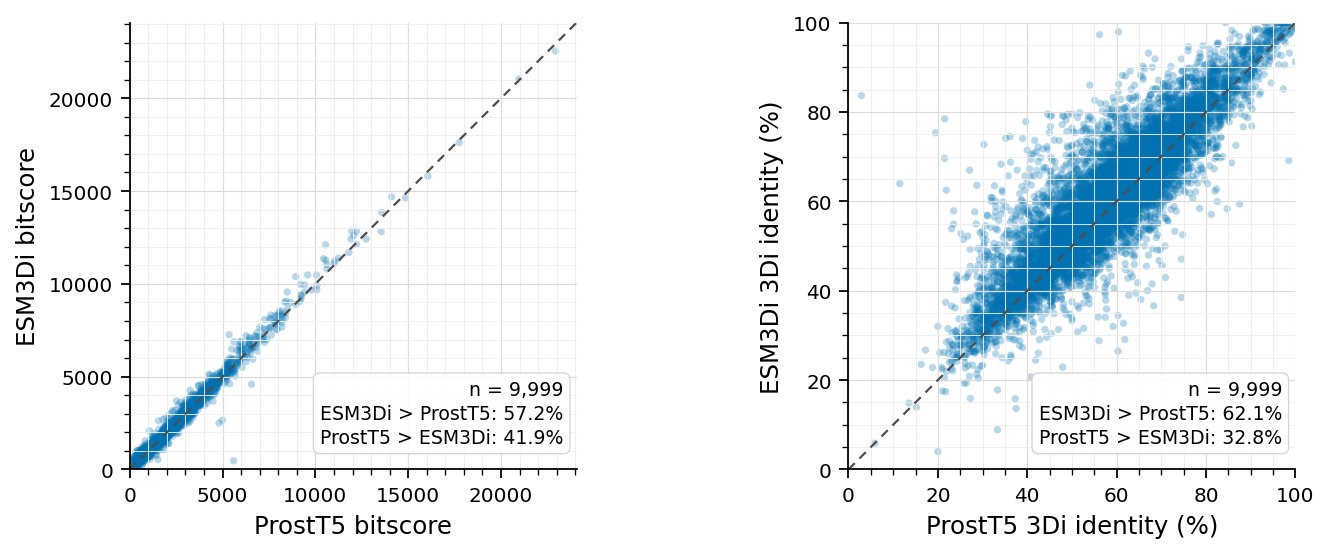

In [29]:
import matplotlib.pyplot as plt
import numpy as np


def plot_benchmark_comparison(
    df,
    x_col,
    y_col,
    x_label,
    y_label,
    ax,
):
    """Plot one benchmark comparison with matched axes and manuscript styling."""
    values = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    x = values[x_col].to_numpy()
    y = values[y_col].to_numpy()

    if len(x) == 0:
        ax.text(0.5, 0.5, "No finite observations", ha="center", va="center")
        return

    n_total = len(x)
    n_above = np.count_nonzero(y > x)
    n_below = np.count_nonzero(y < x)
    pct_above = 100 * n_above / n_total
    pct_below = 100 * n_below / n_total

    max_val = max(x.max(), y.max())
    lim = 100.0 if "identity" in x_col.lower() and max_val <= 100 else max_val * 1.05
    lim = max(lim, 1.0)

    ax.scatter(
        x,
        y,
        s=11,
        alpha=0.28,
        color="#0072B2",
        edgecolors="none",
        rasterized=True,
    )
    ax.plot(
        [0, lim],
        [0, lim],
        color="#4D4D4D",
        linestyle=(0, (4, 3)),
        linewidth=1.0,
        zorder=2,
    )

    ax.set(
        xlim=(0, lim),
        ylim=(0, lim),
        xlabel=x_label,
        ylabel=y_label,
        aspect="equal",
    )

    stats_text = (
        f"n = {n_total:,}\n"
        f"ESM3Di > ProstT5: {pct_above:.1f}%\n"
        f"ProstT5 > ESM3Di: {pct_below:.1f}%"
    )
    ax.text(
        0.97,
        0.05,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5,
        linespacing=1.35,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "0.82",
            "linewidth": 0.6,
            "alpha": 0.9,
        },
    )

    ax.minorticks_on()
    ax.grid(
        True,
        which="major",
        color="0.86",
        linestyle="-",
        linewidth=0.55,
        zorder=0,
    )
    ax.grid(
        True,
        which="minor",
        color="0.93",
        linestyle="-",
        linewidth=0.4,
        zorder=0,
    )
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=2.5,
        width=0.6,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)


plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.2, 4.0),
    dpi=160,
    gridspec_kw={"wspace": 0.28},
    constrained_layout=True,
)

plot_benchmark_comparison(
    df=df_benchmark,
    x_col="prostt5_bitscore",
    y_col="esm3di_bitscore",
    x_label="ProstT5 bitscore",
    y_label="ESM3Di bitscore",
    ax=axes[0],
)

plot_benchmark_comparison(
    df=df_benchmark,
    x_col="prostt5_identity",
    y_col="esm3di_identity",
    x_label="ProstT5 3Di identity (%)",
    y_label="ESM3Di 3Di identity (%)",
    ax=axes[1],
)

plt.show()